# CFRM 521/421 Machine Learning for Finance
## Course Project Template

**Project Title:**

**Group Members:**  
- Qingyu (Wendy) Mao (email: qingym6@uw.edu, Algorithm: SVR)  
- Konoka Hamada (email: konokh@uw.edu, Algorithm: Baseline linear regression)  
- Xiran Zhang (email: xiran712@uw.edu, Algorithm: Decision tree)  
- Polina Loukiantchikov (email: polinal@uw.edu, Algorithm: Regularized regression)  

**Date:**
05/29/2026


# 1. Introduction (Polina)

## 1.1 Problem Statement

Our project will apply machine learning methods to predict housing prices in King County, Washington. This is an important problem at the intersection of real estate, economics, and mathematics; researchers are constantly seeking new methods of predicting future house pricing. Housing prices are crucial for real estate valuation, investment decisions, and housing market risk analysis.

## 1.2 Related Literature

A directly related study was conducted by researchers at Queen's University, where they test eight models (mainly variations of gradient boosting) on King County house pricing data to determine the most influential features (Wang & Zhao, 2022). A 2024 ResearchGate paper does a similar comparison; a researcher used linear regression, random forest, and neural networks for prediction (Li, 2024).

## 1.3 Contribution

Our contribution is mainly empirical comparison. Most prior work focuses on one or two main models; we are running four distinct models with consistent metrics across each of them, which most papers do not implement.

# 2. Data Description (Konoka)

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


In [2]:
# Load your data here
# Example:
# df = pd.read_csv('your_data.csv')
# df.head()

url = "https://raw.githubusercontent.com/p0linal1/CFRM-421-Project/refs/heads/main/kc_house_data.csv"
df = pd.read_csv(url)

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# For 2.2

# Check the structure of the dataset
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

# Convert date column to datetime and check the time period
df["date"] = pd.to_datetime(df["date"])

print("\nEarliest sale date:", df["date"].min())
print("Latest sale date:", df["date"].max())

# Check target variable
print("\nTarget variable summary:")
print(df["price"].describe())

# Check missing values
print("\nMissing values by column:")
print(df.isnull().sum())

Dataset shape: (21613, 21)

Column names:
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

Earliest sale date: 2014-05-02 00:00:00
Latest sale date: 2015-05-27 00:00:00

Target variable summary:
count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

Missing values by column:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd
import numpy as np

# copy of the original dataframe
data = df.copy()

# convert sale date and create date-based feature
data["date"] = pd.to_datetime(data["date"])
data["sale_year"] = data["date"].dt.year
data["sale_month"] = data["date"].dt.month

data["was_renovated"] = (data["yr_renovated"] > 0).astype(int)

# Target variable
y = data["price"]

# Features for all models
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "was_renovated",
    "zipcode",
    "lat",
    "long",
    "sale_year",
    "sale_month"
]

X = data[features]

# zipcode is treated as categorical
categorical_features = ["zipcode"]
numeric_features = [col for col in features if col not in categorical_features]

# preprocessing for the models
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Training set shape: (17290, 18)
Test set shape: (4323, 18)
Number of numerical features: 17
Number of categorical features: 1


The dataset contains 21,613 residential property sales from King County, Washington, covering the period from May 2014 to May 2015. Each observation represents a single housing transaction. The target variable is the sale price of the property. No missing values were identified in the dataset. Several preprocessing steps were performed, including feature engineering based on transaction dates and renovation status, one-hot encoding of zipcode, standardization of numerical features, and an 80/20 train-test split. No observations were removed as outliers, since extreme prices correspond to genuine luxury properties rather than data errors.

# 3. Exploratory Data Analysis (Wendy)

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [5]:
# Basic summary statistics
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631


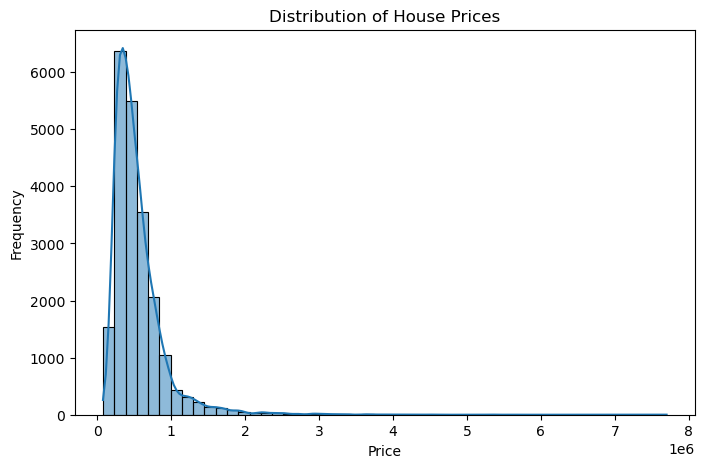

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The distribution is highly right-skewed, with most homes selling between approximately 200,000 and 800,000 dollars, while a small number of luxury properties exceed several million dollars. This indicates the presence of extreme high-value observations, which is common in real estate markets.

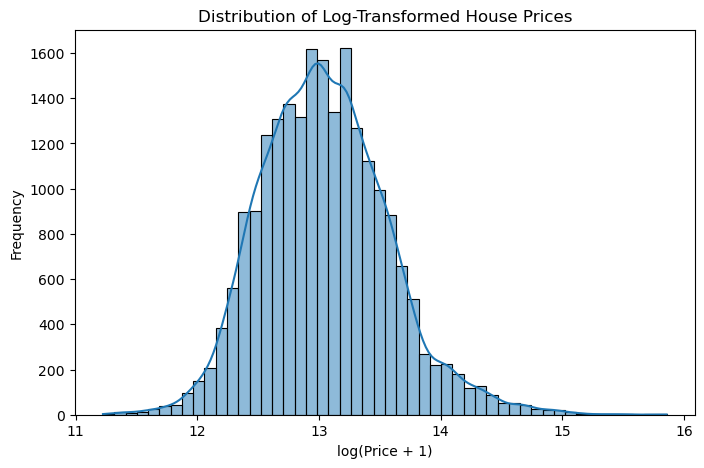

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Distribution of Log-Transformed House Prices")
plt.xlabel("log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

To better understand the distribution of the target variable, a logarithmic transformation was applied to house prices. As shown in the figure above, the transformed distribution is substantially more symmetric and closer to a normal distribution. This suggests that a log transformation may be beneficial for certain modeling approaches, particularly linear regression models that often perform better when the response variable is approximately normally distributed.

In [8]:
corr_matrix = df.corr(numeric_only=True)

corr_with_price = (
    corr_matrix["price"]
    .sort_values(ascending=False)
)

print(corr_with_price)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


Living area `sqft_living` exhibits the strongest correlation with house prices (0.702), followed by house quality `grade` and above-ground living area `sqft_above`. The feature `sqft_living15`, defined as the square footage of interior living space for the nearest 15 neighboring houses, also shows a strong positive correlation with price (0.585). This suggests that neighborhood characteristics play an important role in determining property values. Interestingly, the number of bathrooms `bathrooms` has a substantially stronger correlation with price (0.525) than the number of bedrooms `bedrooms` (0.308), indicating that overall house size, quality, and amenities may be more important determinants of housing value than simply the number of bedrooms.

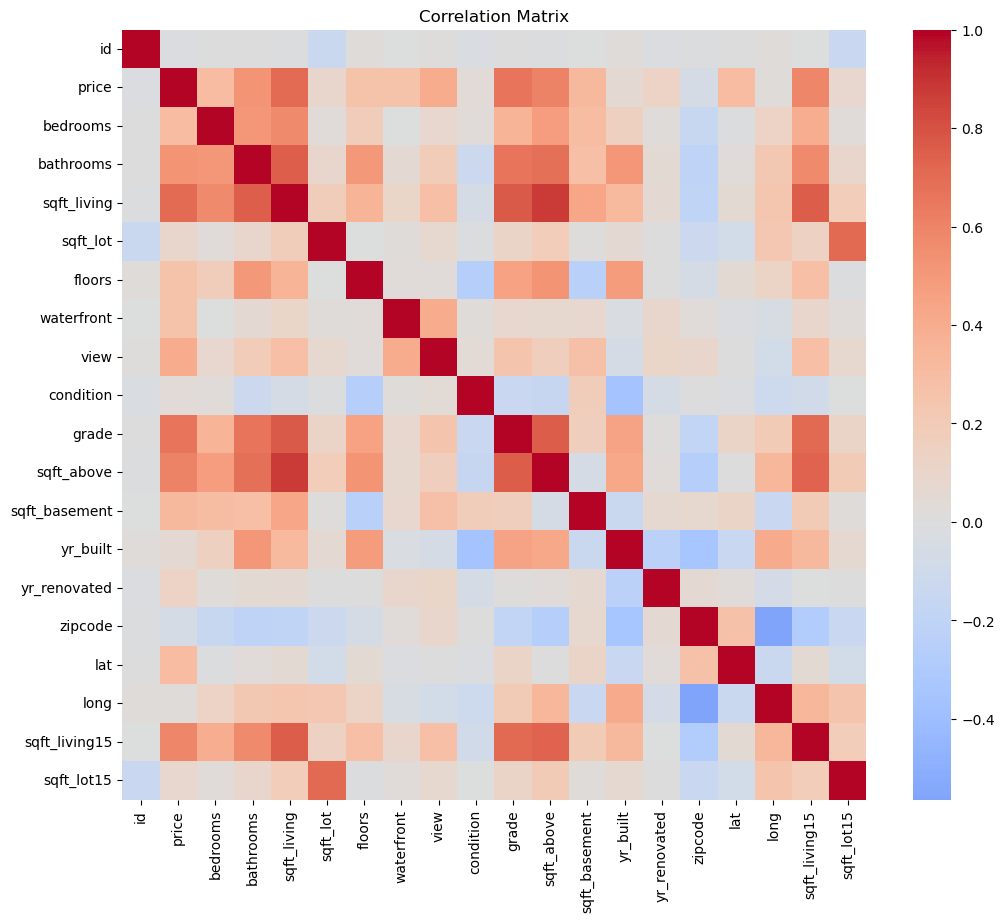

In [9]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

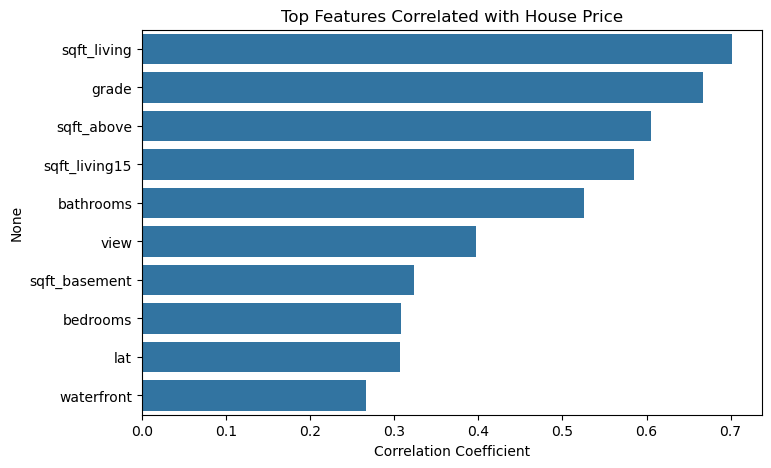

In [10]:
top_corr = corr_with_price.drop("price").head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with House Price")
plt.xlabel("Correlation Coefficient")
plt.show()

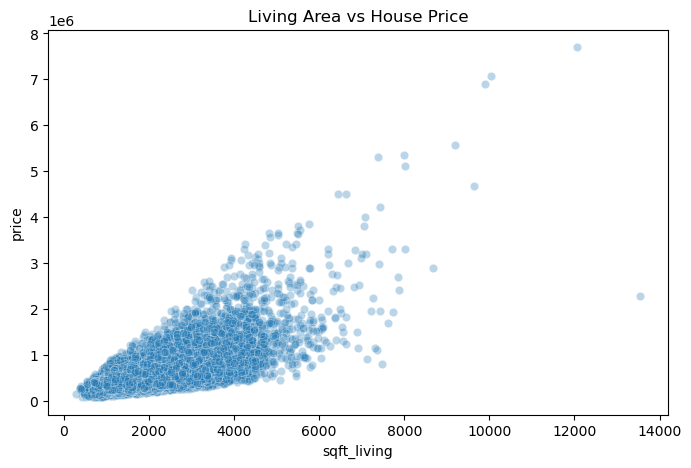

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price",
    alpha=0.3
)

plt.title("Living Area vs House Price")
plt.show()

This figure shows a strong positive relationship between living area and house price. However, price variability increases among larger homes, indicating that additional factors such as location and quality also influence property values.

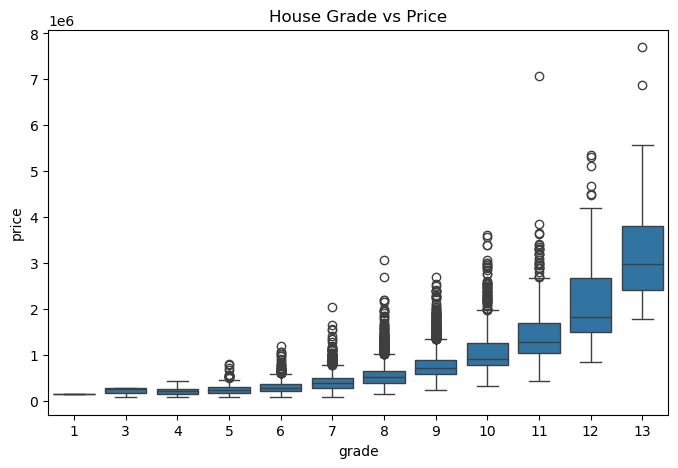

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="grade",
    y="price"
)

plt.title("House Grade vs Price")
plt.show()

House prices increase consistently with higher construction quality ratings. Properties with grades above 10 command substantially higher prices than lower-grade homes, highlighting the importance of construction quality and design.

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: Basic Linear Regression

**Implemented by:**

- Motivation
- Model description
- Why this method is appropriate/Key assumptions


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)


linear_model.fit(X_train, y_train)


y_pred_linear = linear_model.predict(X_test)


rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("Baseline Linear Regression Results")
print(f"RMSE: ${rmse_linear:,.2f}")
print(f"MAPE: {mape_linear:.2f}%")

Baseline Linear Regression Results
RMSE: $170,382.42


NameError: name 'mape_linear' is not defined

## 4.3 Model 2: ___

**Implemented by:**

- Motivation
- Model description
- Why this method is appropriate

## 4.4 Model 3: SVR

**Implemented by:** Qingyu (Wendy) Mao

- Motivation
- Model description
- Why this method is appropriate

SVR was selected because the exploratory analysis suggested that the relationship between housing features and sale prices is not purely linear. By using kernel functions, SVR can capture more complex patterns and may improve prediction accuracy.

Support Vector Regression (SVR) is a machine learning method used for predicting continuous values. It attempts to find a function that minimizes prediction error while maintaining model simplicity. In this project, the RBF kernel was used to model nonlinear relationships in the data.

SVR is appropriate for housing price prediction because property values depend on multiple interacting factors such as size, quality, and location. Since the relationships between these variables and price are not strictly linear, SVR provides a flexible approach for capturing more complex patterns.

In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Use log-transformed target for SVR
svr_y_train_log = np.log1p(y_train)

svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(
            kernel="rbf",
            C=10,
            epsilon=0.1,
            gamma="scale"
        ))
    ]
)

svr_model.fit(X_train, svr_y_train_log)

# Predict log prices, then convert back to dollar prices
svr_y_pred_log = svr_model.predict(X_test)
svr_y_pred = np.expm1(svr_y_pred_log)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_y_pred))
svr_mae = mean_absolute_error(y_test, svr_y_pred)
svr_r2 = r2_score(y_test, svr_y_pred)

print("SVR Results with Log-Transformed Target")
print(f"RMSE: ${svr_rmse:,.2f}")
print(f"MAE: ${svr_mae:,.2f}")
print(f"R²: {svr_r2:.4f}")

SVR Results with Log-Transformed Target
RMSE: $178,143.83
MAE: $78,787.60
R²: 0.7901


In [ ]:
from sklearn.model_selection import GridSearchCV

svr_param_grid = {
    "model__C": [1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__gamma": ["scale", "auto"]
}

svr_grid_search = GridSearchCV(
    svr_model,
    svr_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

svr_grid_search.fit(X_train, svr_y_train_log)

svr_best_model = svr_grid_search.best_estimator_

svr_y_pred_log_tuned = svr_best_model.predict(X_test)
svr_y_pred_tuned = np.expm1(svr_y_pred_log_tuned)

svr_rmse_tuned = np.sqrt(mean_squared_error(y_test, svr_y_pred_tuned))
svr_mae_tuned = mean_absolute_error(y_test, svr_y_pred_tuned)
svr_r2_tuned = r2_score(y_test, svr_y_pred_tuned)

print("Tuned SVR Results")
print("Best parameters:", svr_grid_search.best_params_)
print(f"RMSE: ${svr_rmse_tuned:,.2f}")
print(f"MAE: ${svr_mae_tuned:,.2f}")
print(f"R²: {svr_r2_tuned:.4f}")

Tuned SVR Results
Best parameters: {'model__C': 10, 'model__epsilon': 0.1, 'model__gamma': 'auto'}
RMSE: $130,838.68
MAE: $68,987.09
R²: 0.8868


To improve model performance, a grid search with 3-fold cross-validation was performed over the SVR hyperparameters. The search considered different values of C, epsilon, and gamma. The best-performing model used C = 10, epsilon = 0.1, and gamma = 'auto'.

After tuning, the SVR model achieved an RMSE of \$130,838.68, an MAE of \$68,987.09, and an R² of 0.8868 on the test set. Compared with the initial SVR model, hyperparameter tuning significantly improved predictive performance, indicating that model selection and parameter optimization play an important role in housing price prediction.

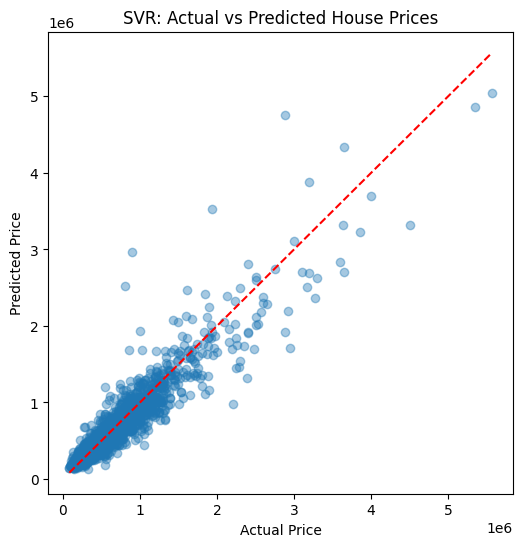

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    svr_y_pred_tuned,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

This figure compares the actual and predicted house prices generated by the tuned SVR model. Most observations lie close to the 45-degree reference line, indicating strong predictive performance. However, prediction errors become larger for extremely expensive properties, suggesting that luxury homes are more difficult to model accurately due to their limited representation in the dataset.

## 4.5 Model 4: Regularized Regression

**Implemented by:** Polina Loukiantchikov

Linear regression assumes that all features contribute meaningfully to price prediction, which can lead to overfitting. Regularized regression addresses this by penalizing model complexity, shrinking coefficients toward zero to reduce variance.

Two regularized forms of linear regression, Ridge and Lasso, are implemented. Lasso can shrink coefficients all the way down to zero (performing feature selection), while ridge shrinks them close to zero. 

In this dataset, multicollinearity is likely, and regularization addresses this issue directly. Lasso will likely be more useful here because it can identify which zipcodes or structural features are truly predictive and zero out the rest, making the model more interpretable.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ridge Regression
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso Regression
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=10000))
])
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print("Ridge (default α=1.0):")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_ridge):,.2f}")
print(f"R²: {r2_score(y_test, y_pred_ridge):.4f}")

print("\nLasso (default α=1.0):")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_lasso)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lasso):,.2f}")
print(f"R²: {r2_score(y_test, y_pred_lasso):.4f}")

# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [ ]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

Wang, Y., & Zhao, Q. (2022). House price prediction based on machine learning: A case of King County. In Proceedings of the 2022 7th International Conference on Financial Innovation and Economic Development (ICFIED 2022) (pp. 1547–1555). Atlantis Press. https://doi.org/10.2991/aebmr.k.220307.253

Li, C. (2024). House price prediction using machine learning. ResearchGate. https://www.researchgate.net/publication/379367913